<a href="https://colab.research.google.com/github/sherbo16/health-wise-ai-70/blob/main/Implementation_of_Movie_Recommender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

column_names = ['user_id', 'item_id', 'rating', 'timestamp']

path = '/content/Tamil_movies_dataset.csv'

df = pd.read_csv(path, names=column_names)

df.head()

,,,,,,user_id,item_id,rating,timestamp
MovieName,Genre,Rating,Director,Actor,PeopleVote,Year,Hero_Rating,movie_rating,content_rating
Mouna Guru,Action,7.7,Santha Kumar,Arulnithi,746,2011,8,8,7.9
7 Aum Arivu,Action,6.2,A.R. Murugadoss,Suriya,9479,2011,9,9,8.066666667
Vaagai Sooda Vaa,Comedy,8,A. Sarkunam,Vimal,14522,2011,8,7,7.666666667
Mankatha,Action,7.6,Venkat Prabhu,Ajith Kumar,12276,2011,6,8,7.2


In [11]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1J2aeSDR0uOE_vmpZAJKOJfH4KxyypEXvI2_-JX7XcKU/edit#gid=0


In [14]:
movie_titles = pd.read_csv('/content/Movie_Id_Titles')
movie_titles.head()

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [17]:
df['item_id'] = pd.to_numeric(df['item_id'], errors='coerce')
df.dropna(subset=['item_id'], inplace=True)
df['item_id'] = df['item_id'].astype(int)
data = pd.merge(df, movie_titles, on='item_id')
data.head()

,user_id,item_id,rating,timestamp,title
0,2011,8,8,7.9,Babe (1995)
1,2011,9,9,8.066666667,Dead Man Walking (1995)
2,2011,8,7,7.666666667,Babe (1995)
3,2011,6,8,7.2,Shanghai Triad (Yao a yao yao dao waipo qiao) ...
4,2011,8,9,7.833333333,Babe (1995)


In [19]:
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')
data.dropna(subset=['rating'], inplace=True)
data.groupby('title')['rating'].mean().sort_values(ascending=False).head()

,rating
title,
Richard III (1995),8.500000
Copycat (1995),8.294118
Get Shorty (1995),8.275862
Toy Story (1995),8.250000
Twelve Monkeys (1995),8.166667


In [20]:
data.groupby('title')['rating'].count().sort_values(ascending=False).head()

,rating
title,
Babe (1995),95
Dead Man Walking (1995),56
Twelve Monkeys (1995),54
Copycat (1995),51
Get Shorty (1995),29


In [21]:
ratings = pd.DataFrame(data.groupby('title')['rating'].mean())

ratings['num of ratings'] = pd.DataFrame(data.groupby('title')['rating'].count())

ratings.head()

,rating,num of ratings
title,,
Babe (1995),8.021053,95
Copycat (1995),8.294118,51
Dead Man Walking (1995),8.160714,56
Four Rooms (1995),7.833333,6
Get Shorty (1995),8.275862,29


In [22]:
sns.set_style('white')
%matplotlib inline

<Axes: >

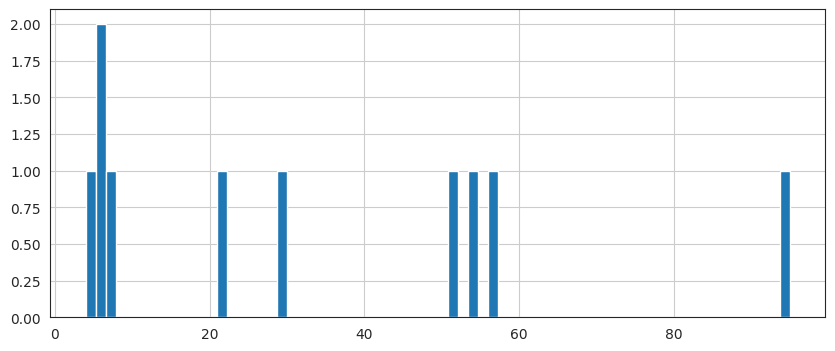

In [23]:
plt.figure(figsize =(10, 4))

ratings['num of ratings'].hist(bins = 70)

<Axes: >

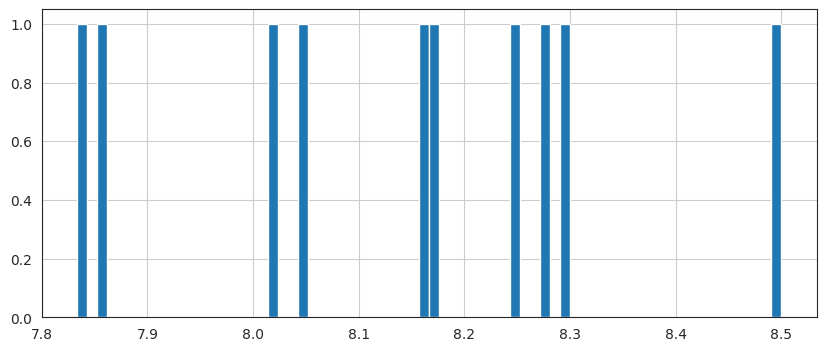

In [24]:
plt.figure(figsize =(10, 4))

ratings['rating'].hist(bins = 70)

In [25]:
moviemat = data.pivot_table(index ='user_id',
              columns ='title', values ='rating')

moviemat.head()

ratings.sort_values('num of ratings', ascending = False).head(10)

,rating,num of ratings
title,,
Babe (1995),8.021053,95
Dead Man Walking (1995),8.160714,56
Twelve Monkeys (1995),8.166667,54
Copycat (1995),8.294118,51
Get Shorty (1995),8.275862,29
Shanghai Triad (Yao a yao yao dao waipo qiao) (1995),8.047619,21
GoldenEye (1995),7.857143,7
Four Rooms (1995),7.833333,6
Richard III (1995),8.500000,6


In [27]:
babe_user_ratings = moviemat['Babe (1995)']
deadman_user_ratings = moviemat['Dead Man Walking (1995)']

babe_user_ratings.head()

,Babe (1995)
user_id,
2011,8.250000
2012,9.000000
2013,8.166667
2014,7.571429
2015,8.500000


In [29]:
similar_to_babe = moviemat.corrwith(babe_user_ratings)
similar_to_deadman = moviemat.corrwith(deadman_user_ratings)

corr_babe = pd.DataFrame(similar_to_babe, columns =['Correlation'])
corr_babe.dropna(inplace = True)

corr_babe.head()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,Correlation
title,
Babe (1995),1.000000
Copycat (1995),-0.047116
Dead Man Walking (1995),0.392698
Four Rooms (1995),-0.328087
Get Shorty (1995),0.331846


In [31]:
corr_babe.sort_values('Correlation', ascending = False).head(10)
corr_babe = corr_babe.join(ratings['num of ratings'])

corr_babe.head()

corr_babe[corr_babe['num of ratings']>100].sort_values('Correlation', ascending = False).head()

,Correlation,num of ratings
title,,


In [33]:
corr_deadman = pd.DataFrame(similar_to_deadman, columns =['Correlation'])
corr_deadman.dropna(inplace = True)

corr_deadman = corr_deadman.join(ratings['num of ratings'])
corr_deadman[corr_deadman['num of ratings']>100].sort_values('Correlation', ascending = False).head()

,Correlation,num of ratings
title,,
